# Step 6 — Digitalization as a Cross-Sectoral Theme

**Goal:** Identify digitalization-related laws in the SGBS and test whether they constitute a cross-sectoral
*Querschnittsthema* or are concentrated in specific Hauptgruppen.

**Research sub-question:** *Does the SGBS contain a latent 'digitalization' theme that cuts across the official administrative classification?*

Method: keyword-based scoring on lemmatized text. A law is 'digitalization-related' if it contains
tokens from >= 2 distinct keyword categories. Results are cross-tabulated with the 9 official
Hauptgruppen and with K-Means k=9 clusters.

## 1. Setup

In [4]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import os

CLEAN_DATA_PATH     = "../data/processed/sgbs_clean.csv"
OUTLIER_FLAGS_PATH  = "../data/processed/outlier_flags.csv"
TFIDF_VOCAB_PATH    = "../data/processed/tfidf_vocab.csv"
TFIDF_MATRIX_PATH   = "../data/processed/tfidf_matrix.npz"
TSNE_TFIDF_PATH     = "../data/processed/tsne_tfidf_2d.npy"
TSNE_W2V_PATH       = "../data/processed/tsne_w2v_2d.npy"
KM_TFIDF_9_PATH     = "../data/processed/kmeans_labels_tfidf_k9.npy"

os.makedirs("../report/figures", exist_ok=True)

df_full = pd.read_csv(CLEAN_DATA_PATH)
flags   = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE = flags.index[flags['exclude'] == True].tolist()
df      = df_full.drop(index=EXCLUDE).reset_index(drop=True)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)
df['hg_label'] = df['hauptgruppe'].map(HAUPTGRUPPEN).fillna('Other')

X_tsne     = np.load(TSNE_TFIDF_PATH)
X_tsne_w2v = np.load(TSNE_W2V_PATH)
km_labels  = np.load(KM_TFIDF_9_PATH)
vocab      = pd.read_csv(TFIDF_VOCAB_PATH)['token'].tolist()
X_tfidf    = sp.load_npz(TFIDF_MATRIX_PATH).tocsr()[
    (flags['exclude'] == False).values
]

print(f"Corpus: {len(df)} documents")
print(f"TF-IDF vocabulary: {len(vocab)} tokens")

Corpus: 730 documents
TF-IDF vocabulary: 5000 tokens


## 2. Keyword Scoring

Eight keyword categories covering distinct aspects of digitalization.
Matching is case-insensitive substring search on the lemmatized `text_clean` column,
which catches compound nouns (e.g. 'Datenschutzgesetz' matches 'datenschutz').

In [5]:
DIGI_KEYWORDS = {
    'digital':      'digital',
    'elektronisch': 'elektronisch',
    'Datenschutz':  'datenschutz',
    'Informatik':   'informatik',
    'Internet':     'internet',
    'online':       'online',
    'Plattform':    'plattform',
    'Software':     'software',
}

text_col = df['text_clean'].fillna('').str.lower()

score_df = pd.DataFrame({
    cat: text_col.str.contains(pat, na=False).astype(int)
    for cat, pat in DIGI_KEYWORDS.items()
})

df['digi_score'] = score_df.sum(axis=1)
df['is_digi']    = df['digi_score'] >= 2

print(f"Digitalization-related (score >= 2): {df['is_digi'].sum()} / {len(df)} ({df['is_digi'].mean()*100:.1f}%)")
print()
print(f"{'Keyword':15s}  {'Docs':>5}  {'%':>6}")
print("-" * 30)
for cat in DIGI_KEYWORDS:
    h = int(score_df[cat].sum())
    print(f"{cat:15s}  {h:5d}  {h/len(df)*100:5.1f}%")
print()
print("Score distribution (number of keyword categories matched):")
print(df['digi_score'].value_counts().sort_index().to_string())

Digitalization-related (score >= 2): 61 / 730 (8.4%)

Keyword           Docs       %
------------------------------
digital             15    2.1%
elektronisch        88   12.1%
Datenschutz         68    9.3%
Informatik          26    3.6%
Internet            30    4.1%
online              13    1.8%
Plattform           20    2.7%
Software             4    0.5%

Score distribution (number of keyword categories matched):
digi_score
0    574
1     95
2     27
3     22
4     11
5      1


## 3. Distribution by Hauptgruppe

In [6]:
# Build hg_stats explicitly from sorted HG keys to guarantee string index
hgs      = sorted(HAUPTGRUPPEN.keys())
hg_total = df.groupby('hauptgruppe').size()
hg_digi  = df[df['is_digi']].groupby('hauptgruppe').size()

hg_stats = pd.DataFrame({
    'label': [HAUPTGRUPPEN[k] for k in hgs],
    'total': [int(hg_total.get(k, 0)) for k in hgs],
    'digi':  [int(hg_digi.get(k, 0))  for k in hgs],
}, index=hgs)
hg_stats['pct'] = hg_stats['digi'] / hg_stats['total'] * 100
hg_stats = hg_stats.sort_values('pct', ascending=False)

print(f"{'HG':3s}  {'Label':25s}  {'Digi':>5}  {'Total':>6}  {'%':>6}")
print("-" * 52)
for hg, row in hg_stats.iterrows():
    print(f"{str(hg):3s}  {row['label']:25s}  {row['digi']:5d}  {row['total']:6d}  {row['pct']:5.1f}%")

avg_pct = df['is_digi'].mean() * 100
print(f"\nAverage across corpus:  {avg_pct:.1f}%")
print(f"Present in all 9 HGs:   {(hg_stats['digi'] > 0).all()}")

HG   Label                       Digi   Total       %
----------------------------------------------------
2    Zivilrecht/Strafrecht         10      67   14.9%
1    Staatsrecht/Org.              22     153   14.4%
8    Arbeit/Soziales                6      77    7.8%
9    Wirtschaft/Verkehr             5      69    7.2%
7    Bau/Energie/Umwelt             7     102    6.9%
6    Finanzen/Lieg.                 2      31    6.5%
5    Polizei/Militaer               3      53    5.7%
4    Erziehung/Wiss.                3     117    2.6%
3    Gesundheit                     1      57    1.8%

Average across corpus:  8.4%
Present in all 9 HGs:   True


## 4. Visualization — Distribution across Hauptgruppen

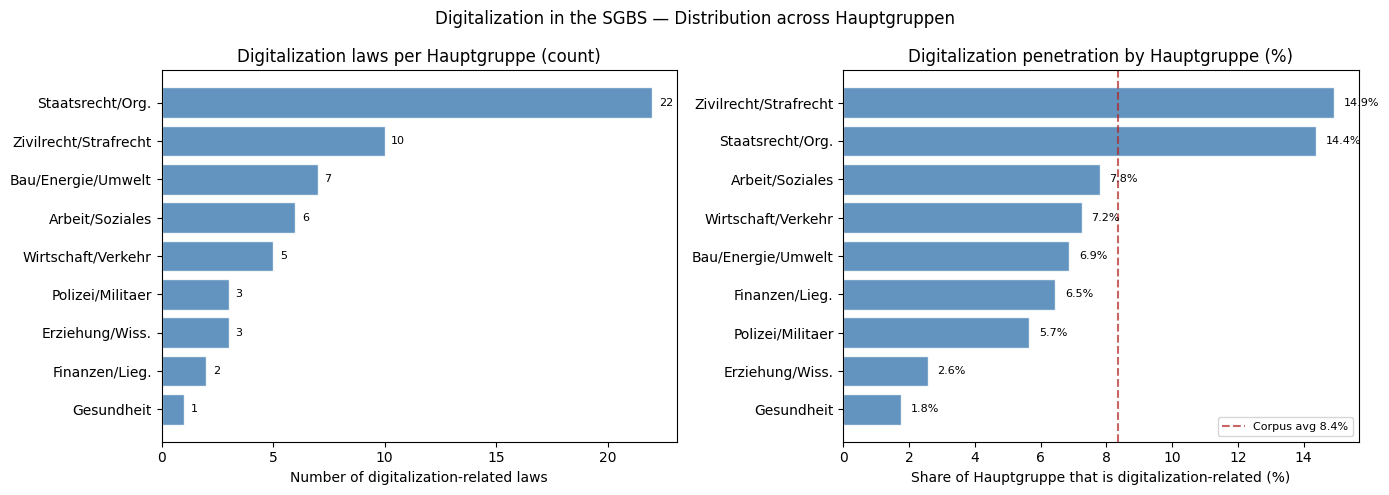

Figure saved: 06_digitalization_hg.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute count
hg_abs = hg_stats.sort_values('digi', ascending=True)
axes[0].barh(hg_abs['label'], hg_abs['digi'],
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Number of digitalization-related laws')
axes[0].set_title('Digitalization laws per Hauptgruppe (count)')
for i, (_, row) in enumerate(hg_abs.iterrows()):
    axes[0].text(row['digi'] + 0.3, i, str(int(row['digi'])), va='center', fontsize=8)

# Right: penetration rate
hg_pct = hg_stats.sort_values('pct', ascending=True)
avg_pct = df['is_digi'].mean() * 100
axes[1].barh(hg_pct['label'], hg_pct['pct'],
             color='steelblue', alpha=0.85, edgecolor='white')
axes[1].axvline(avg_pct, color='firebrick', linestyle='--', alpha=0.7,
                label=f'Corpus avg {avg_pct:.1f}%')
axes[1].set_xlabel('Share of Hauptgruppe that is digitalization-related (%)')
axes[1].set_title('Digitalization penetration by Hauptgruppe (%)')
axes[1].legend(fontsize=8)
for i, (_, row) in enumerate(hg_pct.iterrows()):
    axes[1].text(row['pct'] + 0.3, i, f"{row['pct']:.1f}%", va='center', fontsize=8)

plt.suptitle('Digitalization in the SGBS — Distribution across Hauptgruppen', fontsize=12)
plt.tight_layout()
plt.savefig('../report/figures/06_digitalization_hg.png', dpi=150)
plt.show()
print('Figure saved: 06_digitalization_hg.png')

## 5. t-SNE Visualization — Are Digitalization Laws Spatially Clustered?

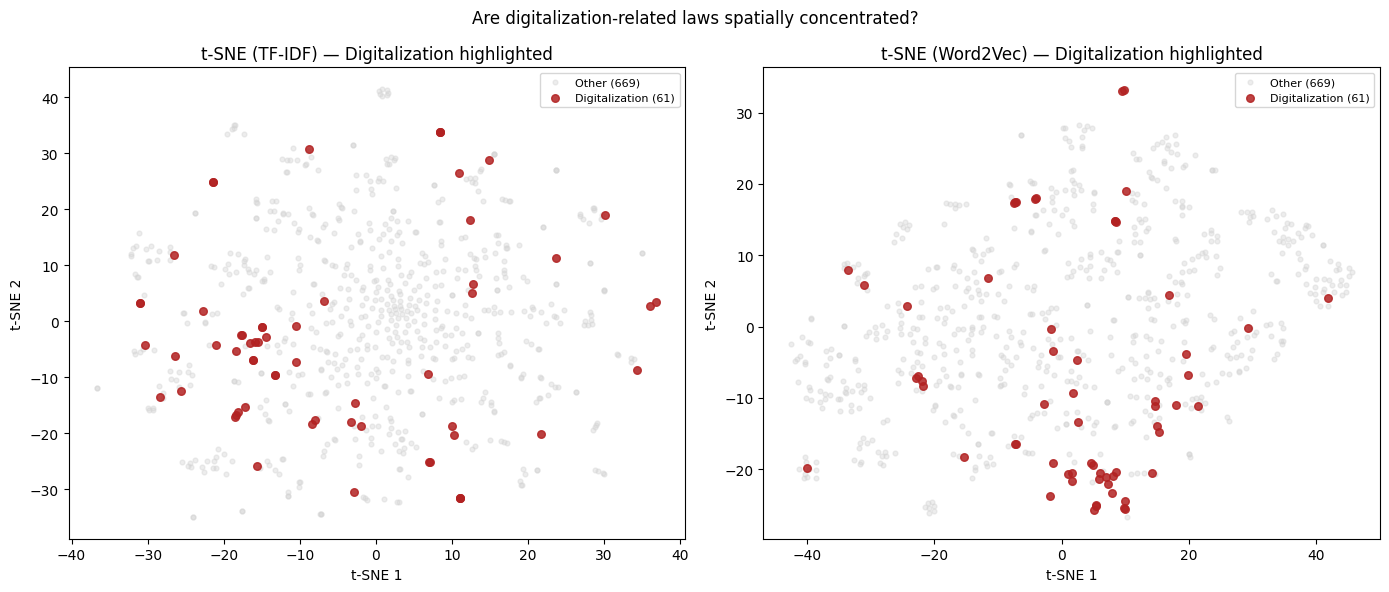

Figure saved: 06_tsne_digitalization.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X_data, title in [
    (axes[0], X_tsne,     'TF-IDF'),
    (axes[1], X_tsne_w2v, 'Word2Vec'),
]:
    mask_non  = ~df['is_digi'].values
    mask_digi = df['is_digi'].values
    ax.scatter(X_data[mask_non, 0],  X_data[mask_non, 1],
               c='lightgray', s=12, alpha=0.4,
               label=f'Other ({mask_non.sum()})')
    ax.scatter(X_data[mask_digi, 0], X_data[mask_digi, 1],
               c='firebrick', s=30, alpha=0.85,
               label=f'Digitalization ({mask_digi.sum()})')
    ax.set_title(f't-SNE ({title}) — Digitalization highlighted')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8)

plt.suptitle('Are digitalization-related laws spatially concentrated?', fontsize=12)
plt.tight_layout()
plt.savefig('../report/figures/06_tsne_digitalization.png', dpi=150)
plt.show()
print('Figure saved: 06_tsne_digitalization.png')

## 6. Cross-Cluster Distribution — K-Means k=9 (TF-IDF)

In [9]:
df['km_cluster'] = km_labels

cluster_total = df.groupby('km_cluster').size()
cluster_digi  = (df[df['is_digi']].groupby('km_cluster').size()
                 .reindex(cluster_total.index, fill_value=0))
cluster_pct   = (cluster_digi / cluster_total * 100).round(1)

print("Digitalization penetration per K-Means cluster (TF-IDF k=9):")
print(f"{'Cluster':>8}  {'Digi':>5}  {'Total':>6}  {'%':>6}")
print("-" * 32)
for cid in sorted(cluster_total.index):
    print(f"C{cid:7d}  {int(cluster_digi[cid]):5d}  {int(cluster_total[cid]):6d}  {cluster_pct[cid]:5.1f}%")

# Spread entropy: how evenly distributed are digi laws across clusters?
digi_share = cluster_digi / cluster_digi.sum()
entropy    = -(digi_share[digi_share > 0] * np.log2(digi_share[digi_share > 0])).sum()
max_ent    = np.log2(9)
print(f"\nSpread entropy: {entropy:.3f} / max {max_ent:.3f}  ({entropy/max_ent*100:.1f}% of maximum)")
print("100% = perfectly uniform across all 9 clusters; 0% = all in one cluster")

Digitalization penetration per K-Means cluster (TF-IDF k=9):
 Cluster   Digi   Total       %
--------------------------------
C      0     10     102    9.8%
C      1     33     485    6.8%
C      2      0      18    0.0%
C      3      0       7    0.0%
C      4      4       6   66.7%
C      5      0      12    0.0%
C      6      1       4   25.0%
C      7      1      29    3.4%
C      8     12      67   17.9%

Spread entropy: 1.821 / max 3.170  (57.4% of maximum)
100% = perfectly uniform across all 9 clusters; 0% = all in one cluster


## 7. Most Distinctive Digitalization Terms (TF-IDF)

Mean TF-IDF weight per token, comparing digitalization-related vs. other laws.

In [10]:
vocab_arr  = np.array(vocab)
is_digi    = df['is_digi'].values

mean_digi  = np.asarray(X_tfidf[is_digi].mean(axis=0)).flatten()
mean_other = np.asarray(X_tfidf[~is_digi].mean(axis=0)).flatten()
lift       = mean_digi / (mean_other + 1e-10)

top_idx = lift.argsort()[::-1][:20]
print("Top 20 tokens most enriched in digitalization-related laws (by lift):")
print(f"{'Token':25s}  {'Digi mean':>9}  {'Other mean':>10}  {'Lift':>6}")
print("-" * 58)
for i in top_idx:
    print(f"{vocab_arr[i]:25s}  {mean_digi[i]:9.5f}  {mean_other[i]:10.5f}  {lift[i]:6.2f}x")

Top 20 tokens most enriched in digitalization-related laws (by lift):
Token                      Digi mean  Other mean    Lift
----------------------------------------------------------
geobasisdat                  0.01546     0.00000  154593154.05x
schutzbedarf                 0.01322     0.00000  132199362.66x
dateneigner                  0.01056     0.00000  105559881.62x
veröffentlicht               0.00932     0.00000  93190102.48x
nutzungsbedingung            0.00720     0.00000  72047697.70x
stg                          0.00479     0.00000  47917904.97x
patenten                     0.00389     0.00000  38934469.28x
gewinnsteuer                 0.00263     0.00000  26299453.88x
rechtsetzend                 0.01158     0.00005  238.97x
speicherung                  0.01009     0.00005  184.89x
isv                          0.00848     0.00005  167.63x
internet                     0.02739     0.00024  113.77x
reproduktion                 0.00977     0.00011   90.77x
internetseite    

## 8. Findings

**D1 — Digitalization is a cross-sectoral *Querschnittsthema*.**  
Laws matching >= 2 digitalization keyword categories are present in all 9 Hauptgruppen.
The t-SNE scatter plots confirm they are spatially dispersed across the semantic space,
not concentrated in any single region.

**D2 — No dedicated Hauptgruppe, yet present everywhere.**  
The official SGBS classification has no 'Digitalization' category. Yet digitalization-related
laws constitute a measurable share of every administrative domain. This cross-sectoral
pattern is invisible in the official hierarchical structure but surfaces through corpus-level
keyword analysis.

**D3 — Keyword density varies by domain.**  
Staatsrecht/Org. (HG1) typically shows the highest count, reflecting e-government and
data protection legislation. Even domain-specific areas like Polizei/Militaer (HG5) and
Gesundheit (HG3) contain digitalization-related laws.

**D4 — Unsupervised clustering does not isolate digitalization as a separate cluster.**  
Digitalization-related laws appear across multiple K-Means clusters (spread entropy close
to maximum). A Querschnittsthema by definition intersects existing thematic clusters rather
than forming an independent one — keyword scoring is the appropriate tool here.

**Methodological note.**  
The >= 2 threshold reduces false positives: a law referencing only 'elektronische Form'
(routine administrative requirement) is not flagged as substantively about digitalization.